# Flip-Angle-Reihe – Gaußpuls auf Wasserpool
Simuliert Gaußpulse mit Flipwinkeln von 0° bis 180° und stellt transversale und longitudinale Magnetisierung gemeinsam dar.

In [7]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from bmc.simulate import simulate
from bmc.utils.seq.write import write_seq
from bmc.utils.results import save_simulation, load_simulation

## Einstellungen

In [8]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve().parent  # one level up: optim/
config_path = wdir / 'sim_lib' / 'config_1pool.yaml'
seq_tmp_dir = wdir / 'seq_lib' / 'flip_angle_series'
seq_tmp_dir.mkdir(parents=True, exist_ok=True)

# Ausgabe-Ordner für alle Simulationen dieser Reihe
series_label = f"flip_angle_series_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
series_dir   = wdir / 'results' / 'simulations' / series_label
series_dir.mkdir(parents=True, exist_ok=True)

# ── Flipwinkel-Reihe: 10° bis 90° in 20°-Schritten ────────────────────────
flip_angles_deg = np.arange(10, 91, 20)   # 10°, 30°, 50°, 70°, 90°  (5 Werte)

# ── Sequenz-Parameter ──────────────────────────────────────────────────────
sys = pp.Opts(
    max_grad=500,
    grad_unit='mT/m',
    max_slew=1e9,
    slew_unit='T/m/s',
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)

B0        = 17        # [T]
t_pulse   = 2e-3      # [s]
adc_time  = 1.0       # [s]  — covers ~14 × T2 (full decay) and ~0.4 × T1 (recovery onset)

GAMMA_HZ  = sys.gamma * 1e-6
freq_hz   = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 100
z_pos = np.linspace(low, high, n_iso)
z_pos = torch.tensor(z_pos)
z_pos = torch.cat((z_pos, torch.tensor([0.0])))
z_pos = torch.sort(z_pos).values

print(f"Flipwinkel: {flip_angles_deg}")
print(f"adc_time:   {adc_time} s")
print(f"Ergebnisse werden gespeichert in: {series_dir}")

Flipwinkel: [10 30 50 70 90]
adc_time:   1.0 s
Ergebnisse werden gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308


## Sequenzen erstellen, simulieren und speichern

In [9]:
result_dirs = {}   # fa_deg -> Path

for fa_deg in flip_angles_deg:
    print(f"\n── {fa_deg}° ──")

    # ── Sequenz erzeugen ──────────────────────────────────────────────────
    defs = {
        'a':          float(fa_deg),
        'b0':         B0,
        'm0_offset':  0,
        'n_ETM':      1,
        'seq_id_string': f'fa_{int(fa_deg):03d}',
    }
    defs['offsets_ppm'] = np.array([defs['m0_offset']])
    defs['num_meas']    = int(defs['offsets_ppm'].size)
    defs['freq']        = freq_hz

    seq = pp.Sequence()

    if fa_deg == 0:
        seq.add_block(pp.make_delay(t_pulse))
    else:
        rf = pp.make_gauss_pulse(
            flip_angle=np.radians(fa_deg),
            system=sys,
            duration=t_pulse,
            center_pos=0.5,
            freq_offset=0.0,
            phase_offset=0.0,
            return_gz=False,
        )
        rf.freq_offset = 0.0
        seq.add_block(rf)

    # ADC directly after pulse — no dead-time delay
    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))

    seq_file = seq_tmp_dir / f"fa_{int(fa_deg):03d}.seq"
    write_seq(seq=seq, seq_defs=defs, filename=seq_file, author='DANIEL MIKSCH', use_matlab_names=True)

    # ── Simulation ────────────────────────────────────────────────────────
    sim = simulate(
        config_file=config_path,
        seq_file=seq_file,
        z_positions=z_pos,
        adc_time=adc_time,
        iso_select=None,
        return_zmag=False,
        show_plot=False,
        webhook=False,
        plt_range=[0, 4],
        n_backlog='ALL',
    )

    # ── Speichern ─────────────────────────────────────────────────────────
    out = save_simulation(sim, label=f"fa_{int(fa_deg):03d}", results_root=series_dir)
    result_dirs[float(fa_deg)] = out
    print(f"   gespeichert: {out.name}")

print(f"\n✓ Alle {len(flip_angles_deg)} Simulationen gespeichert in:\n  {series_dir}")



── 10° ──


BMCTool simulation: 100%|██████████| 2/2 [00:00<00:00,  4.26it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308/fa_010_20260517_172308
   gespeichert: fa_010_20260517_172308

── 30° ──


BMCTool simulation: 100%|██████████| 2/2 [00:00<00:00,  4.80it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308/fa_030_20260517_172309
   gespeichert: fa_030_20260517_172309

── 50° ──


...

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308/fa_050_20260517_172309
   gespeichert: fa_050_20260517_172309

── 70° ──


BMCTool simulation: 100%|██████████| 2/2 [00:00<00:00,  4.73it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308/fa_070_20260517_172310
   gespeichert: fa_070_20260517_172310

── 90° ──


BMCTool simulation: 100%|██████████| 2/2 [00:00<00:00,  4.82it/s]

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308/fa_090_20260517_172310
   gespeichert: fa_090_20260517_172310

✓ Alle 5 Simulationen gespeichert in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308


## Ergebnisse laden und gemeinsam plotten

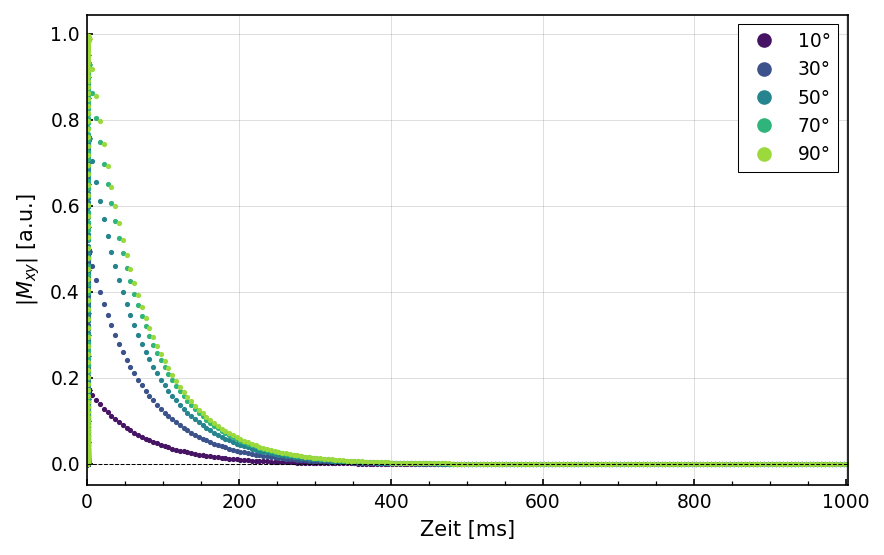

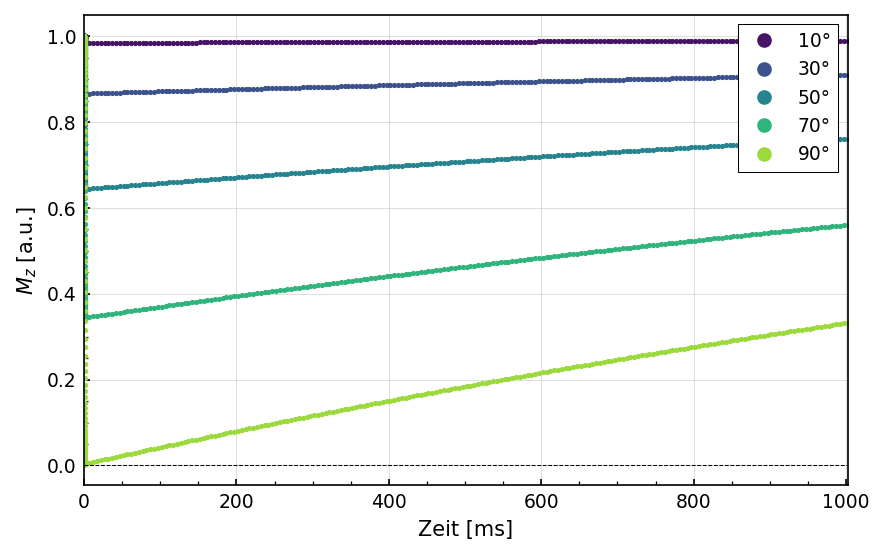


Plots gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308


In [10]:
import matplotlib as mpl
import matplotlib.cm as cm

# ── Plot-Stil ──────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'text.usetex':         False,
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.labelsize':      10,
    'axes.titlesize':      11,
    'legend.fontsize':     9,
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'axes.linewidth':      0.8,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.size':    3,
    'ytick.major.size':    3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth':     1.2,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# ── Daten laden ────────────────────────────────────────────────────────────
# State vector layout (1 water + 1 CEST pool, n_total_pools=2):
# [Mx_w, Mx_cest, My_w, My_cest, Mz_w, Mz_cest, M0_w, M0_cest]
#   0      1       2     3        4      5
n_total_pools = 2   # 1 water + 1 CEST pool
mz_loc        = 4   # = 2 * n_total_pools

fa_list = sorted(result_dirs.keys())
n_fa    = len(fa_list)

# Viridis: use range [0.05, 0.85] to avoid too-bright yellow on white
cmap   = cm.viridis
colors = [cmap(0.05 + 0.80 * i / max(n_fa - 1, 1)) for i in range(n_fa)]

MARKER_SIZE = 3

trans_data = {}
long_data  = {}
t_max      = 0.0

for fa_deg in fa_list:
    loaded       = load_simulation(result_dirs[fa_deg])
    m_out        = loaded['m_out']
    t            = loaded['t']
    n_iso_loaded = m_out.shape[0]

    m_x = np.sum(m_out[:, 0,            :], axis=0) / n_iso_loaded  # Mx_water
    m_y = np.sum(m_out[:, n_total_pools, :], axis=0) / n_iso_loaded  # My_water
    m_z = np.sum(m_out[:, mz_loc,        :], axis=0) / n_iso_loaded  # Mz_water

    t_ms = t * 1e3
    mask = t_ms >= 0
    t_ms = t_ms[mask]
    trans_data[fa_deg] = (t_ms, np.abs(m_x + 1j * m_y)[mask])
    long_data[fa_deg]  = (t_ms, m_z[mask])
    t_max = max(t_max, t_ms[-1])

# ── Plot 1: Transversale Magnetisierung ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 3.8))

for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = trans_data[fa_deg]
    ax1.plot(t_ms, signal, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}°')

ax1.set_xlabel('Zeit [ms]')
ax1.set_ylabel('$|M_{xy}|$ [a.u.]')
ax1.set_xlim(0, t_max)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg1 = ax1.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg1.get_frame().set_linewidth(0.5)

fig1.tight_layout()
fig1.savefig(series_dir / 'transverse_magnetization.pdf')
fig1.savefig(series_dir / 'transverse_magnetization.png')
plt.show()

# ── Plot 2: Longitudinale Magnetisierung ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 3.8))

for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = long_data[fa_deg]
    ax2.plot(t_ms, signal, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}°')

ax2.set_xlabel('Zeit [ms]')
ax2.set_ylabel('$M_z$ [a.u.]')
ax2.set_xlim(0, t_max)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg2 = ax2.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg2.get_frame().set_linewidth(0.5)

fig2.tight_layout()
fig2.savefig(series_dir / 'longitudinal_magnetization.pdf')
fig2.savefig(series_dir / 'longitudinal_magnetization.png')
plt.show()

print(f"\nPlots gespeichert in: {series_dir}")


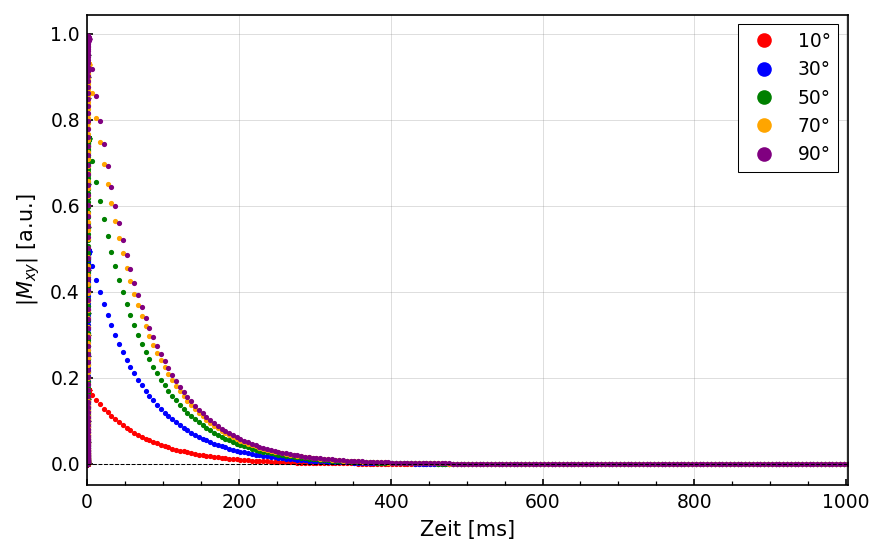

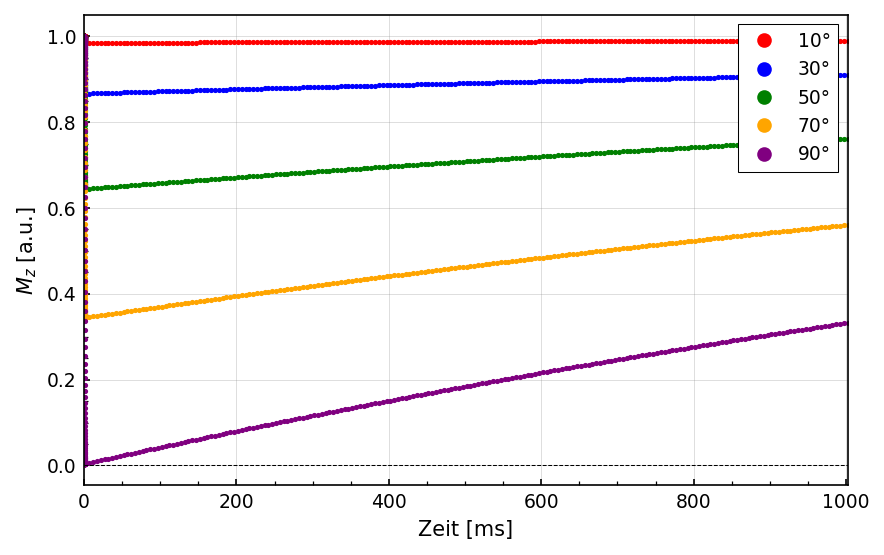

Backup-Plots gespeichert als *_classic.pdf / *_classic.png in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308


In [11]:
# ── Backup: klassische Farbgebung (rot / blau / grün / orange / lila) ──────
COLORS_OLD = ['red', 'blue', 'green', 'orange', 'purple']
colors_old = COLORS_OLD[:n_fa]

fig3, ax3 = plt.subplots(figsize=(6, 3.8))
for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = trans_data[fa_deg]
    ax3.plot(t_ms, signal, '.', color=colors_old[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}°')
ax3.set_xlabel('Zeit [ms]')
ax3.set_ylabel('$|M_{xy}|$ [a.u.]')
ax3.set_xlim(0, t_max)
ax3.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax3.grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg3 = ax3.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg3.get_frame().set_linewidth(0.5)
fig3.tight_layout()
fig3.savefig(series_dir / 'transverse_magnetization_classic.pdf')
fig3.savefig(series_dir / 'transverse_magnetization_classic.png')
plt.show()

fig4, ax4 = plt.subplots(figsize=(6, 3.8))
for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = long_data[fa_deg]
    ax4.plot(t_ms, signal, '.', color=colors_old[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}°')
ax4.set_xlabel('Zeit [ms]')
ax4.set_ylabel('$M_z$ [a.u.]')
ax4.set_xlim(0, t_max)
ax4.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax4.grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg4 = ax4.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg4.get_frame().set_linewidth(0.5)
fig4.tight_layout()
fig4.savefig(series_dir / 'longitudinal_magnetization_classic.pdf')
fig4.savefig(series_dir / 'longitudinal_magnetization_classic.png')
plt.show()

print(f"Backup-Plots gespeichert als *_classic.pdf / *_classic.png in:\n  {series_dir}")

## Split-Panel-Plot: Puls | FID

Linkes Panel: Dynamik während des Gauß-Pulses (0 – 2 ms).  
Rechtes Panel: FID / T₁-Erholung nach dem Puls (2 – 52 ms).  
Beide Panels teilen dieselbe y-Achse. Diagonale Striche markieren den Achsenbruch.

/var/folders/_s/ymfv76ms5rs0hd9l43mh92_80000gn/T/ipykernel_68101/1786473049.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


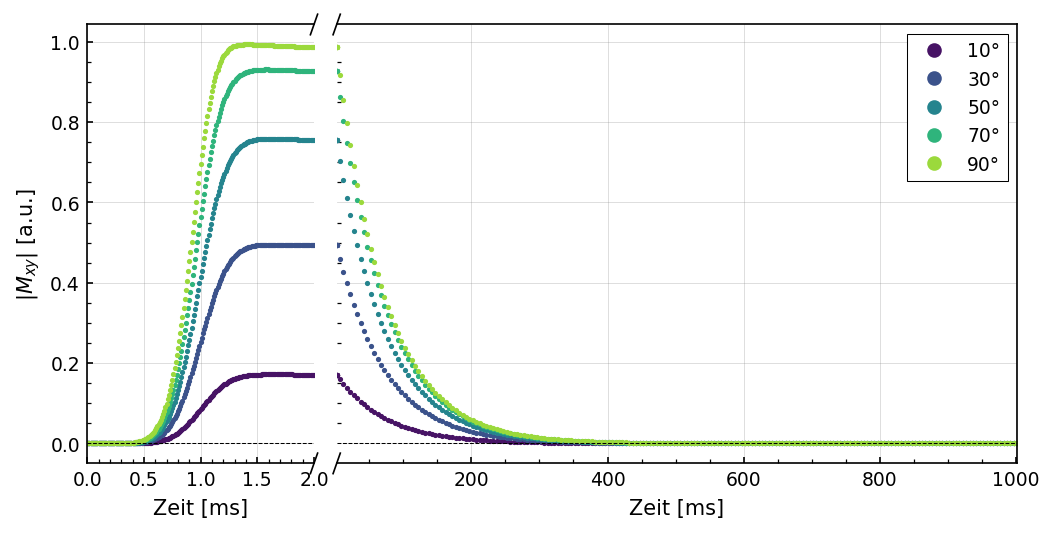

/var/folders/_s/ymfv76ms5rs0hd9l43mh92_80000gn/T/ipykernel_68101/1786473049.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


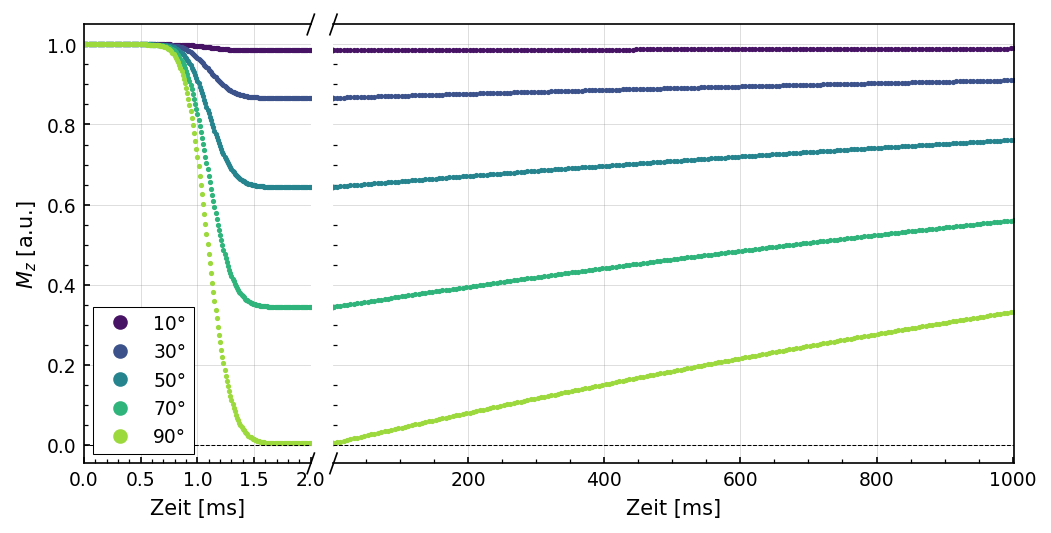

Split-Panel Plots gespeichert in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260517_172308


In [12]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

t_split = t_pulse * 1e3  # pulse end [ms]  →  2.0 ms

plot_configs = [
    ('transverse',   trans_data, '$|M_{xy}|$ [a.u.]', 'right', 'upper right', 'transverse_magnetization_split'),
    ('longitudinal', long_data,  '$M_z$ [a.u.]',      'left',  'lower left',  'longitudinal_magnetization_split'),
]

for name, data_dict, ylabel, leg_panel, leg_loc, fname in plot_configs:

    fig = plt.figure(figsize=(8, 3.8))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.05, figure=fig)
    ax_l = fig.add_subplot(gs[0])
    ax_r = fig.add_subplot(gs[1], sharey=ax_l)

    for idx, fa_deg in enumerate(fa_list):
        t_ms, signal = data_dict[fa_deg]
        kw = dict(color=colors[idx], markersize=MARKER_SIZE, linestyle='none')

        mask_l = t_ms <= t_split + 0.05
        ax_l.plot(t_ms[mask_l], signal[mask_l], '.', label=f'{int(fa_deg)}°', **kw)

        mask_r = t_ms >= t_split - 0.05
        ax_r.plot(t_ms[mask_r], signal[mask_r], '.', **kw)

    ax_l.set_xlim(0, t_split)
    ax_r.set_xlim(t_split, t_max)

    # hide inner spines so the break marks sit cleanly at the gap
    ax_l.spines['right'].set_visible(False)
    ax_r.spines['left'].set_visible(False)
    ax_r.tick_params(left=False)
    plt.setp(ax_r.get_yticklabels(), visible=False)

    ax_l.set_xlabel('Zeit [ms]')
    ax_r.set_xlabel('Zeit [ms]')
    ax_l.set_ylabel(ylabel)

    for ax in (ax_l, ax_r):
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.grid(True, linewidth=0.4, color='gray', alpha=0.3)

    # legend on the chosen panel; handles always come from ax_l (where labels are set)
    leg_ax = ax_r if leg_panel == 'right' else ax_l
    handles, labels = ax_l.get_legend_handles_labels()
    leg = leg_ax.legend(handles, labels, loc=leg_loc, frameon=True, fancybox=False,
                        framealpha=1.0, edgecolor='black', markerscale=4)
    leg.get_frame().set_linewidth(0.5)

    # tight_layout first so axes positions are final
    fig.tight_layout()

    # break marks in figure coordinates → identical angle on both panels
    pos_l = ax_l.get_position()
    pos_r = ax_r.get_position()
    dx, dy = 0.003, 0.018
    mark_kw = dict(transform=fig.transFigure, color='k',
                   linewidth=0.8, clip_on=False)
    for x_c in [pos_l.x1, pos_r.x0]:
        for y_c in [pos_l.y0, pos_l.y1]:
            fig.add_artist(Line2D(
                [x_c - dx, x_c + dx], [y_c - dy, y_c + dy], **mark_kw
            ))

    fig.savefig(series_dir / f'{fname}.pdf')
    fig.savefig(series_dir / f'{fname}.png')
    plt.show()

print(f"Split-Panel Plots gespeichert in:\n  {series_dir}")

## Simulationsparameter

### Scanner / Physik
| Parameter | Wert |
|---|---|
| B₀ | 17 T |
| Larmorfrequenz | 723.8 MHz |
| γ (PyPulseq) | 42 576 400 Hz/T |
| γ (Config) | 267.5153 rad/(µT·s) |

### Sequenz
| Parameter | Wert |
|---|---|
| Pulsform | Gauß (center_pos = 0.5) |
| Pulsdauer (t_pulse) | 2 ms |
| Flipwinkel-Reihe | 10°, 30°, 50°, 70°, 90° |
| Delay nach Puls | keiner (ADC direkt nach Puls) |
| ADC | 1 Sample, 1 ms Dauer |
| ADC-Aufzeichnungsfenster | 3 s (~1.2 × T1_water) |
| freq_offset | 0 Hz (on-resonance) |
| phase_offset | 0 |

### PyPulseq Systemparameter
| Parameter | Wert |
|---|---|
| max_grad | 500 mT/m |
| max_slew | 1×10⁹ T/m/s |
| rf_ringdown_time | 0 s |
| rf_dead_time | 0 s |
| rf_raster_time | 1 µs |
| grad_raster_time | 1 µs |

### Isochromaten
| Parameter | Wert |
|---|---|
| Anzahl (n_iso) | 101 (100 gleichmäßig + Zentrum bei 0) |
| Bereich (z_pos) | −1×10⁻³ … +1×10⁻³ |

### Simulationsconfig (`sim_lib/config_1pool.yaml`)
| Pool | f | T₁ [s] | T₂ [ms] | k [Hz] | Δω [ppm] |
|---|---|---|---|---|---|
| Wasser | 1 | 2.5 | 71 | — | 0 |
| Amid (CEST) | 6.49×10⁻⁴ | 1.3 | 100 | 150 | 8 |

| Option | Wert |
|---|---|
| reset_init_mag | True |
| max_pulse_samples | 200 |
| Solver | `torch.linalg.matrix_exp` |